In [ ]:
#day 02 过拟合实验
import os
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 中文显示
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
df = pd.read_csv('D:/MY_Learning/matbench-dielectric/data/dielectric_cleaned.csv') # 绝对路径 jupyter和第一天不一样会报错 
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

# 划分数据（和昨天保持一致）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

训练集大小: 3811
测试集大小: 953


In [10]:
# 训练一个不限制深度的树（最容易过拟合）
dt_overfit = DecisionTreeRegressor(random_state=42)
dt_overfit.fit(X_train, y_train)

# 分别在训练集和测试集上评估
train_pred = dt_overfit.predict(X_train)
test_pred = dt_overfit.predict(X_test)

# 计算指标
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("="*60)
print("不限制深度的决策树（默认参数）")
print("="*60)
print(f"树的深度: {dt_overfit.get_depth()}")
print(f"叶子节点数: {dt_overfit.get_n_leaves()}")
print(f"\n训练集 R²:   {train_r2:.4f}")
print(f"测试集 R²:   {test_r2:.4f}")
print(f"R² 差距:     {train_r2 - test_r2:.4f}")
print(f"\n训练集 RMSE: {train_rmse:.4f}")
print(f"测试集 RMSE: {test_rmse:.4f}")

# 判断是否过拟合
gap = train_r2 - test_r2
if gap > 0.15:
    print(f"\n  严重过拟合！差距 {gap:.2f} > 0.15")
elif gap > 0.05:
    print(f"\n  轻微过拟合，差距 {gap:.2f}")
else:
    print(f"\n 泛化能力良好，差距 {gap:.2f}")

不限制深度的决策树（默认参数）
树的深度: 29
叶子节点数: 3805

训练集 R²:   1.0000
测试集 R²:   0.0697
R² 差距:     0.9303

训练集 RMSE: 0.0000
测试集 RMSE: 0.2514

  严重过拟合！差距 0.93 > 0.15


误差RMSE越小越好 

In [12]:
# 尝试不同的深度
depths = [2, 3, 5, 7, 10, 15, 20, 25, 30, None]
train_scores = []
test_scores = []
tree_depths = []  # 实际深度
n_leaves = []     # 叶子节点数

print("训练不同深度的决策树...\n")
print(f"{'max_depth':<12} {'实际深度':<10} {'叶子数':<10} {'训练R²':<12} {'测试R²':<12} {'差距':<10}")
print("-" * 80)

for depth in depths:
    # 训练模型
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    # 计算分数
    train_score = dt.score(X_train, y_train)
    test_score = dt.score(X_test, y_test)
    
    # 记录
    train_scores.append(train_score)
    test_scores.append(test_score)
    tree_depths.append(dt.get_depth())
    n_leaves.append(dt.get_n_leaves())
    
    # 打印结果
    depth_str = str(depth) if depth is not None else "None"
    gap = train_score - test_score
    print(f"{depth_str:<12} {dt.get_depth():<10} {dt.get_n_leaves():<10} "
          f"{train_score:<12.4f} {test_score:<12.4f} {gap:<10.4f}")

# 找到测试集最佳的 depth
best_idx = np.argmax(test_scores)
best_depth = depths[best_idx]
best_test_score = test_scores[best_idx]

print("\n" + "="*80)
print(f"最佳 max_depth: {best_depth}")
print(f"对应测试集 R²: {best_test_score:.4f}")
print("="*80)

训练不同深度的决策树...

max_depth    实际深度       叶子数        训练R²         测试R²         差距        
--------------------------------------------------------------------------------
2            2          4          0.3840       0.4318       -0.0478   
3            3          8          0.4701       0.4997       -0.0296   
5            5          29         0.6153       0.4932       0.1221    
7            7          92         0.8031       0.4146       0.3885    
10           10         402        0.9377       0.1716       0.7661    
15           15         1934       0.9932       0.1078       0.8853    
20           20         3465       0.9994       0.1278       0.8715    
25           25         3773       1.0000       0.1425       0.8575    
30           29         3805       1.0000       0.0697       0.9303    
None         29         3805       1.0000       0.0697       0.9303    

最佳 max_depth: 3
对应测试集 R²: 0.4997


观察表格：
depth=2-3：欠拟合 规律还没学够
depth>5：过拟合开始

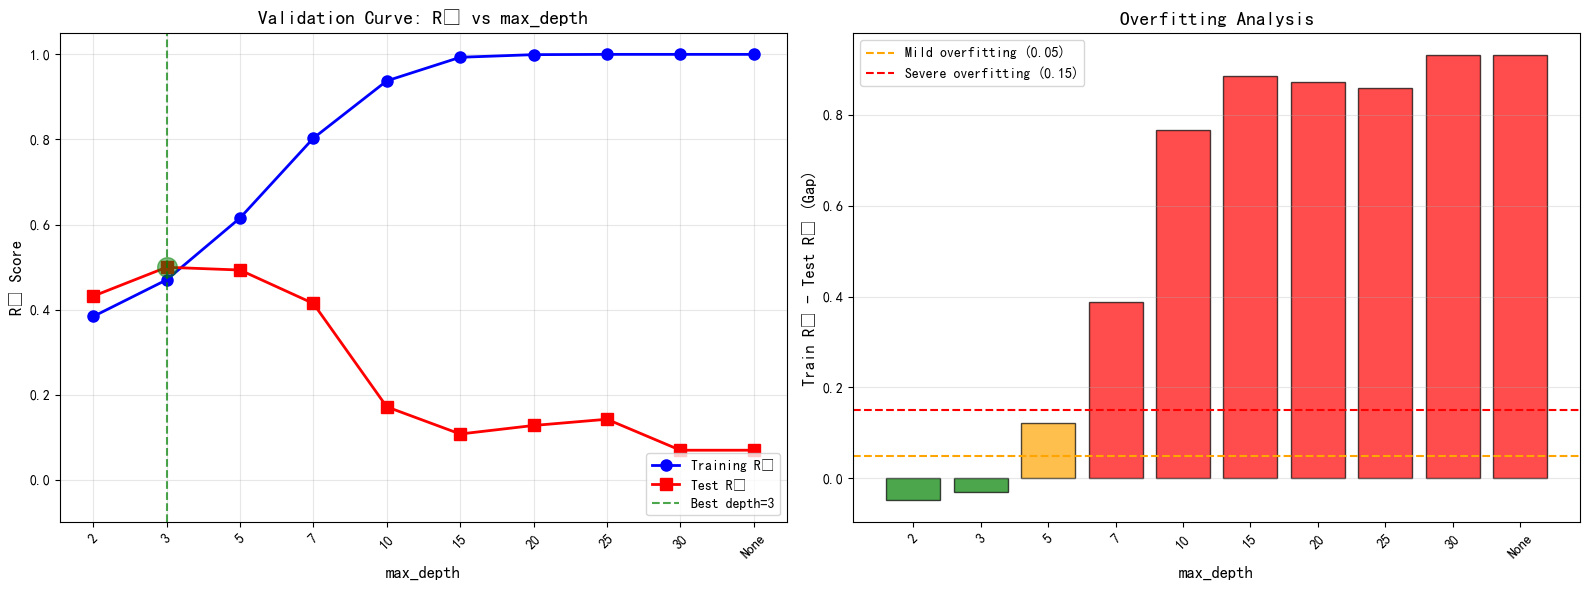


图片已保存到 ../figures/day02_validation_curve.png


In [16]:
# 创建图形
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：R² 曲线
ax1 = axes[0]
x_labels = [str(d) if d is not None else 'None' for d in depths]
x_pos = np.arange(len(depths))

ax1.plot(x_pos, train_scores, marker='o', linewidth=2, 
         markersize=8, label='Training R²', color='blue')
ax1.plot(x_pos, test_scores, marker='s', linewidth=2, 
         markersize=8, label='Test R²', color='red')

# 标注最佳点
ax1.axvline(best_idx, color='green', linestyle='--', alpha=0.7, 
            label=f'Best depth={best_depth}')
ax1.scatter(best_idx, test_scores[best_idx], s=200, 
            color='green', zorder=5, alpha=0.5)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, rotation=45)
ax1.set_xlabel('max_depth', fontsize=12)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('Validation Curve: R² vs max_depth', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([-0.1, 1.05])

# 右图：过拟合程度（训练集和测试集的差距）
ax2 = axes[1]
gaps = np.array(train_scores) - np.array(test_scores)
colors = ['green' if g < 0.05 else 'orange' if g < 0.15 else 'red' for g in gaps]

bars = ax2.bar(x_pos, gaps, color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(0.05, color='orange', linestyle='--', label='Mild overfitting (0.05)')
ax2.axhline(0.15, color='red', linestyle='--', label='Severe overfitting (0.15)')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels, rotation=45)
ax2.set_xlabel('max_depth', fontsize=12)
ax2.set_ylabel('Train R² - Test R² (Gap)', fontsize=12)
ax2.set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('D:/MY_Learning/matbench-dielectric/figures/day02_validation_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n图片已保存到 ../figures/day02_validation_curve.png")

训练集持续上升（蓝线） 但是测试集的红线先升后降  右图的红色是严重过拟合 橙色是轻微过拟合 绿色正常


测试不同的 min_samples_leaf（固定 max_depth=10）...

min_samples_leaf     训练R²         测试R²         差距        
------------------------------------------------------------
1                    0.9377       0.1716       0.7661    
5                    0.7775       0.4649       0.3126    
10                   0.6971       0.5374       0.1597    
20                   0.6487       0.5788       0.0699    
30                   0.6224       0.5871       0.0353    
50                   0.5840       0.5976       -0.0136   
100                  0.5422       0.5832       -0.0410   


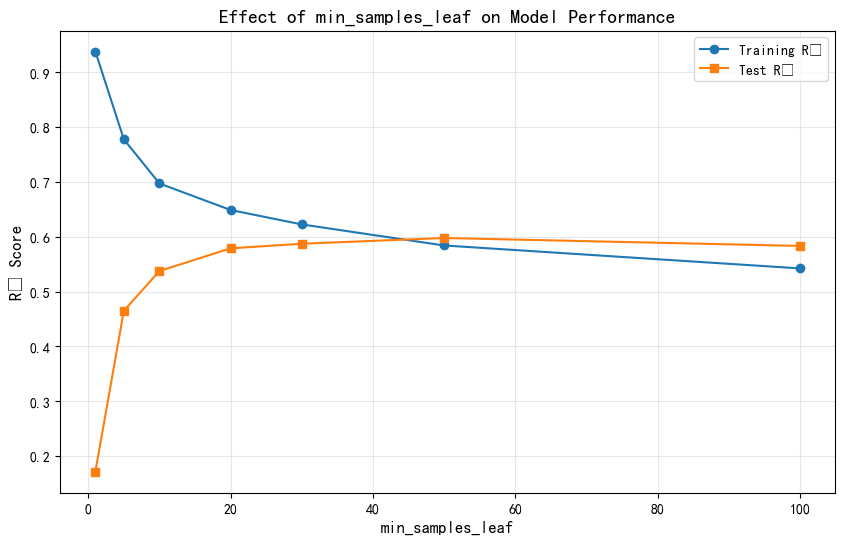

In [18]:
# 固定 max_depth=10，测试不同的 min_samples_leaf
min_samples_values = [1, 5, 10, 20, 30, 50, 100]
train_scores_msl = []
test_scores_msl = []

print("\n测试不同的 min_samples_leaf（固定 max_depth=10）...\n")
print(f"{'min_samples_leaf':<20} {'训练R²':<12} {'测试R²':<12} {'差距':<10}")
print("-" * 60)

for msl in min_samples_values:
    dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=msl, random_state=42)
    dt.fit(X_train, y_train)
    
    train_score = dt.score(X_train, y_train)
    test_score = dt.score(X_test, y_test)
    gap = train_score - test_score
    
    train_scores_msl.append(train_score)
    test_scores_msl.append(test_score)
    
    print(f"{msl:<20} {train_score:<12.4f} {test_score:<12.4f} {gap:<10.4f}")

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(min_samples_values, train_scores_msl, marker='o', label='Training R²')
plt.plot(min_samples_values, test_scores_msl, marker='s', label='Test R²')
plt.xlabel('min_samples_leaf', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Effect of min_samples_leaf on Model Performance', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('D:/MY_Learning/matbench-dielectric/figures/day02_min_samples_leaf.png', dpi=300)
plt.show()

min_samples_leaf很小的时候容易记住噪声还有背答案 训练集很高测试集很低 当达到10-30的时候开始平衡训练和测试集开始接近  30的时候是最佳节点 当超过50的时候差距变成负数欠拟合

In [20]:
from sklearn.model_selection import GridSearchCV

# 定义参数网格
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

print("开始网格搜索（这可能需要几分钟）...\n")

# 创建网格搜索对象
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,              # 5 折交叉验证
    scoring='r2',      # 使用 R² 作为评估指标
    n_jobs=-1,         # 使用所有 CPU 核心
    verbose=1
)

# 执行搜索
grid_search.fit(X_train, y_train)

# 输出最佳参数
print("\n" + "="*80)
print("网格搜索结果")
print("="*80)
print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证 R²: {grid_search.best_score_:.4f}")

# 用最佳参数训练模型
best_dt = grid_search.best_estimator_
test_score_best = best_dt.score(X_test, y_test)
train_score_best = best_dt.score(X_train, y_train)

print(f"\n在测试集上的表现:")
print(f"  训练集 R²: {train_score_best:.4f}")
print(f"  测试集 R²: {test_score_best:.4f}")
print(f"  差距:      {train_score_best - test_score_best:.4f}")
print("="*80)

# 保存最佳模型
import joblib
joblib.dump(best_dt, 'D:/MY_Learning/matbench-dielectric/models/day02_best_tree.pkl')
print("\n最佳模型已保存到 ../models/day02_best_tree.pkl")

开始网格搜索（这可能需要几分钟）...

Fitting 5 folds for each of 45 candidates, totalling 225 fits

网格搜索结果
最佳参数: {'max_depth': 15, 'min_samples_leaf': 20, 'min_samples_split': 50}
最佳交叉验证 R²: 0.4993

在测试集上的表现:
  训练集 R²: 0.6410
  测试集 R²: 0.5842
  差距:      0.0568

最佳模型已保存到 ../models/day02_best_tree.pkl



模型对比
           模型   训练R²   测试R²      差距  深度  叶子数
    默认参数（过拟合） 1.0000 0.0697  0.9303  29 3805
手动调优（depth=3） 0.4701 0.4997 -0.0296   3    8
       网格搜索最优 0.6410 0.5842  0.0568  13  123


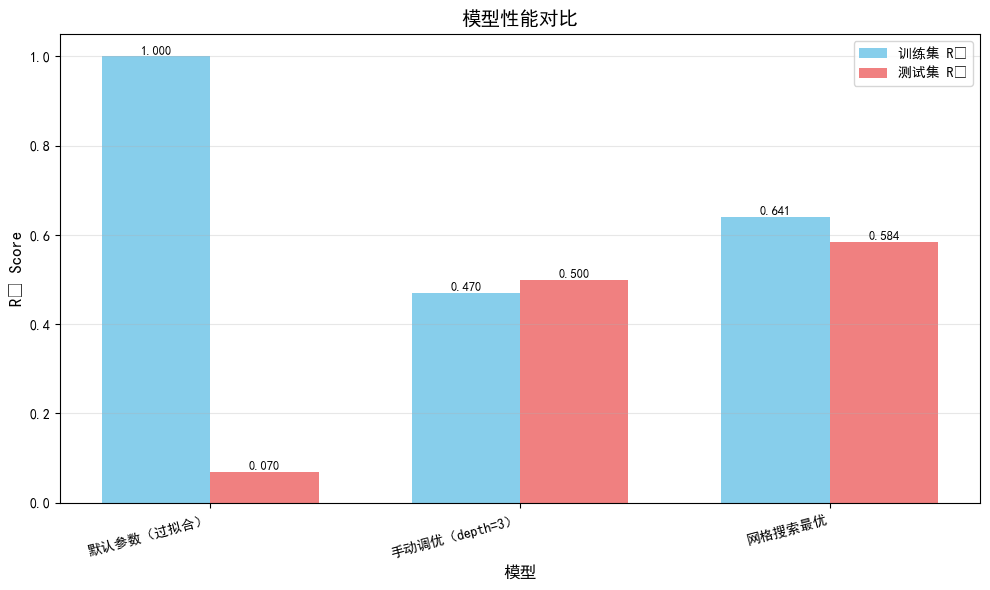

In [26]:
# 对比三个模型
models = {
    '默认参数（过拟合）': dt_overfit,
    f'手动调优（depth={best_depth}）': DecisionTreeRegressor(max_depth=best_depth, random_state=42),
    '网格搜索最优': best_dt
}

# 训练手动调优的模型
models[f'手动调优（depth={best_depth}）'].fit(X_train, y_train)

# 创建对比表格
results = []
for name, model in models.items():
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    gap = train_r2 - test_r2
    
    results.append({
        '模型': name,
        '训练R²': f'{train_r2:.4f}',
        '测试R²': f'{test_r2:.4f}',
        '差距': f'{gap:.4f}',
        '深度': model.get_depth(),
        '叶子数': model.get_n_leaves()
    })

results_df = pd.DataFrame(results)
print("\n" + "="*100)
print("模型对比")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# 可视化对比
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(models))
width = 0.35

train_r2s = [float(r['训练R²']) for r in results]
test_r2s = [float(r['测试R²']) for r in results]

bars1 = ax.bar(x - width/2, train_r2s, width, label='训练集 R²', color='skyblue')
bars2 = ax.bar(x + width/2, test_r2s, width, label='测试集 R²', color='lightcoral')

ax.set_xlabel('模型', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('模型性能对比', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models.keys(), rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.05])

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('D:/MY_Learning/matbench-dielectric/figures/day02_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

思考：有一个问题就是差距的绝对值并不能作为最好的依据，实际上网格搜索最优的训练分数要高一点 ，而且差距只能判断一件事 就是过不过拟合（和0.15比大小） 直觉来讲应该看测试的绝对系数的分数

# Day 2 学习日志

## 1. 什么是过拟合？
就是模型为了强行学习每个数据 然后换个新数据就不好用了 图像上表现就是很贴近每一个数据

## 2. 我的实验结果

### 默认参数
- 训练集 R²: 1.0000
- 测试集 R²: 0.0697
- 差距: 0.9303
- 判断：是否过拟合？严重过拟合

### 最佳参数
- max_depth =13
- min_samples_leaf = 30
- 测试集 R²: 0.5842
- 比默认参数提升了多少？从0.07到0.58
## 3. 从验证曲线学到的关键点

1. depth 太小（<3）会导致：欠拟合就是分数都不高

2. depth 太大（>15）会导致：十分接近1.0

## 4. 今天遇到的问题

问题 1：没加 np.log1p()，测试 R² 全部负数
解决：在 y 那行改用 y = np.log1p(df['n_dielectric'])，复现了 Day 1 的 0.50

问题 1：图里只看到蓝线看不到红线
解决：ax1.set_ylim([0.5, 1.05]) 把测试集的点全切掉了，改成 set_ylim([0, 1.05])
       砍深度防过拟合是笨办法，加 min_samples_leaf 是聪明办法——树可以深，但每片叶子不能随便分